Sara Zivkovic 2022204727


## Generisanje sintetičkih podataka

Implementiramo linearnu regresiju koriscenjem gradijent spusta.Cilj je da se minimizuje funkcija greske i analizira konvergencija modela tokom treninga.
Koristi se sinteticki skup podataka i polinomske karakteristike stepena 2.
Generisemo dataset sa dve ulazne karakteristike a izlazna promenljiva je definisana funkcijom
y = 3x₁ + 2x₂² + 4 + noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Fiksiramo random seed da dobijamo iste rezultate svaki put
np.random.seed(42)

# Broj uzoraka
m = 100

# Generisemo dve ulazne karakteristike
x1 = np.random.rand(m) #1 feature sa 100 slucajnih promenljivih izmedju 0 i 1
x2 = np.random.rand(m)

# Prava funkcija (iz zadatka): y = 3x1 + 2x2^2 + 4 + šum
# Dodajemo mali sum da simuliramo realne podatke
y = 3*x1 + 2*(x2**2) + 4 + np.random.randn(m)*0.1

# Spajamo feature u matricu X
X = np.column_stack((x1, x2))

## Polinomske karakteristike

Dodajemo kvadratne clanove i interakcije izmedju atributa kako bi bilo omoguceno modelu da nauci nelinearne odnose u podacima

Rucno definisanje polinomijalne kaarakteristike za drugi stepen jer je to dovoljno za zadatak, moze se koristiti i opstiji pristup koji automatski generise kombinacije za proizvoljan stepen

In [2]:
def polynomial_features(X):
    """
    Funkcija prosiruje ulazne podatke dodavanjem polinomskih karakteristika.

    Ulaz:
    X = [x1, x2]

    Izlaz:
    [x1, x2, x1^2, x2^2, x1*x2]
    """
    x1 = X[:, 0] #uzmi sve redove iz prve kolone
    x2 = X[:, 1] #uzmi sve redove iz druge kolone

    return np.column_stack((
        x1,        # originalni feature 1
        x2,        # originalni feature 2
        x1**2,     # kvadrat x1
        x2**2,     # kvadrat x2
        x1*x2      # interakcija između x1 i x2
    ))
    #obicna linearna regresija bez prosirenja vidi samo feature x1 i x2
    #ne vidi direktno x2**2
    #column_stack uzima nizove i slaze ih u kolone jedne nove matrice

# Primena transformacije
X_poly = polynomial_features(X)

Dodajemo kolonu jedinica kako bi model imao slobodan clan teta0

In [3]:
def add_bias(X):
    #dodali smo novu kolonu na pocetak matrice to predstavlja niz jedinica odnosno bias theta0

    return np.column_stack((np.ones(X.shape[0]), X))

X_poly = add_bias(X_poly)

Sada koristimo srednju kvadratnu gresku kao meru uspesnosti modela

In [4]:
def compute_mse(X, y, theta):
    """
    Računa MSE (Mean Squared Error)

    Formula:
    MSE = (1/m) * Σ (h(x) - y)^2

    gde je:
    h(x) = X * theta
    """
    m = len(y)

    # Predikcije modela
    predictions = X.dot(theta)

    # Greska (razlika izmedju predikcije i stvarne vrednosti za svaki uzorak)
    error = predictions - y

    # MSE
    #greske se kvadriraju da negativne i pozitivne vr ne mogu da se poniste i velike greske se jace kaznjavaju
    #na kraju se deli sa brojem uzoraka da bi se dobila prosecna greska
    return (1 / m) * np.sum(error**2)

In [5]:
theta_init = np.zeros(X_poly.shape[1])
initial_mse = compute_mse(X_poly, y, theta_init)

print(f"Inicijalni MSE: {initial_mse}")

Inicijalni MSE: 38.183304737239276


## Gradijentni spust

Koristimo gradijentni spust za iterativno azuriranje parametara modela u cilju minimizacije greske

# Gradient descent iterativno azurira parametre modela kako bi minimizovao funkciju greske.

# U svakoj epohi:
# 1. h(x) = Xθ                       → predikcija modela
# 2. J(θ) = (1/m) ∑(h(x) − y)²      → racunanje greske (MSE)
# 3. ∇J(θ) = (2/m) Xᵀ (Xθ − y)      → racunanje gradijenta (pravac rasta greske)
# 4. θ := θ − α ∇J(θ)               → azuriranje parametara

# Gde je:
# θ – vektor parametara (tezine modela)
# α – stopa ucenja (learning rate), odredjuje velicinu koraka
# m – broj uzoraka
# X – matrica ulaznih podataka
# y – stvarne vrednosti
# (Xθ − y) – greska izmedju predikcije i stvarne vrednosti
# ∇J(θ) – gradijent funkcije greske, pokazuje smer najveceg rasta

In [6]:
def gradient_descent(X, y, theta, alpha, epochs):
    """
    Gradient Descent algoritam

    Parametri:
    X - ulazni podaci
    y - stvarne vrednosti
    theta - težine modela
    alpha - learning rate
    epochs - broj iteracija

    Vraća:
    theta - naučene težine
    losses - lista MSE vrednosti kroz iteracije
    """
    m = len(y)
    losses = [] #prazna lista gde se cuva MSE posle svake epohe

    for i in range(epochs):
        # Predikcija modela
        predictions = X.dot(theta) #model sa trenutnim param daje procenu izlaza

        # Greska
        error = predictions - y #racunamo koliko smo promasili

        # Gradijent (izvod MSE po theta)
        gradient = (2 / m) * X.T.dot(error) #kako MSE menja vrednost kada menjamo svaku komponentu od theta
        #X.T je transponovana matrica sto je potrebno da bi dimenzije bile ispravne

        # Azuriranje tezina
        theta = theta - alpha * gradient #gradient kaze u kom smeru MSE raste a mi zelimo da minimizujemo gresku i zato je -, jer se krecemo u suprotnom pravcu
        #alpha je velicina koraka

        # Racunanje loss-a za pracenje konvergencije
        loss = compute_mse(X, y, theta)
        losses.append(loss)

    return theta, losses

Model se trenira kroz vise epoha koristeci zadatu stopu ucenja

In [7]:
# Inicijalizacija tezina (sve vektor nula sto znaci da model na pocetku nema nikakvo znanje a kasnije Gd menja ove vr dok ne nadje bolje param)
#broj elemenata je jednak broju kolona u prosirenoj matrici ulaznih podataka.Svaki el theta vektora predstavlja tezinu jedne karakteristike ukljucujuci i bias
theta = np.zeros(X_poly.shape[1])

# Learning rate
alpha = 0.1

# Broj epoha
epochs = 100

# Treniranje modela
theta, losses = gradient_descent(X_poly, y, theta, alpha, epochs)
#posle treninga theta vise nije niz nula vec naucene tezine
# Konačni MSE nakon treniranja
final_mse = compute_mse(X_poly, y, theta)
print(f"Konačni MSE: {final_mse}")

Konačni MSE: 0.029991353499061756


Koristimo plt za vizualizaciju promene MSE tokom treninga

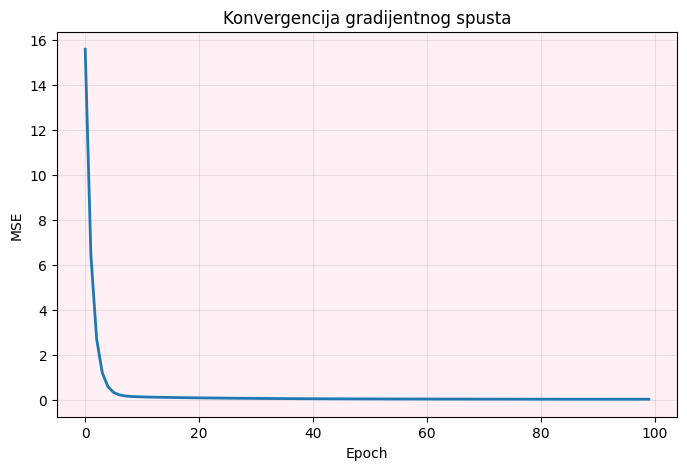

In [8]:
plt.figure(figsize=(8, 5))


plt.plot(losses, linewidth=2)

# boja pozadine
plt.gca().set_facecolor("#fff0f5")   # vrlo svetlo roze

# grid linije (blago roze)
plt.grid(True, alpha=0.3)

# naslovi
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Konvergencija gradijentnog spusta")

plt.show()

1.Uticaj polinomskih karakteristika

Polinomske karakteristike omogucavaju modelu da nauci nelinearne odnose izmedju ulaza i izlaza. U ovom slucaju, model uspesno hvata kvadratni odnos
𝑥
2
2
x
2
2
	​

, koji linearni model bez transformacije ne bi mogao da nauci.

 2.Sta se dešava kada povecamo stepen polinoma

Model postaje fleksibilniji i moze bolje da se prilagodi podacima ali postoji rizik od overfittinga odnosno preprilagodjavanja

 Uticaj learning rate-a

Learning rate (α) određuje brzinu ucenja:

mali α → spora konvergencija

veliki α → moze doći do divergencije i nestabilnosti

##Logisticka regresija od nule



Ponovo gemerisemo sinteticki dataset sa dve karakteristike.
Klase su definisane na osnovu uslova nad ulaznim podacima

In [9]:
# broj uzoraka
m = 100

np.random.seed(42) #seed da bi svaki put dobijali iste slucajne podatke

x1 = np.random.rand(m) #1 feature sa 100 slucajnih promenljivih izmedju 0 i 1
x2 = np.random.rand(m)

# definisemo klase (0 ili 1) odnosno pretvaramo binarni klasifikacioni problem
y_class = (x1 + x2 > 1).astype(int) #uslov tacan true a astype ga pretvara u 1 a ako je false onda je klasa 0

X_class = np.column_stack((x1, x2))#spajamo x1 i x2 u jednu matricu ulaza.Svaki red je jedan uzorak

##Dodajemo vise nelinearnih termina kako bi model mogao da nauci slozenije granice odlucivanja.Osim osnovnih karakteristika dodajemo i vise da bi model mogao da nauci slozeniju granicu odlucivanja, model dobija mnogo bogatiji opis podataka

In [10]:
def polynomial_features_degree3(X):
    x1 = X[:, 0]
    x2 = X[:, 1]

    return np.column_stack((
        x1,
        x2,
        x1**2,
        x2**2,
        x1*x2,
        x1**3,
        x2**3,
        x1**2 * x2,
        x1 * x2**2
    ))

X_poly_class = polynomial_features_degree3(X_class)

##Dodajemo bias koristeci istu add_bias funkciju kao u prvom zadatku sto znaci da dodajemo kolonu jedinica na pocetak matrice da bi model ponovo imao slobodan clan theta0

In [11]:
X_poly_class = add_bias(X_poly_class)

##Sigmoid funkcija
Sigmoid funkcija mapira vrednosti u interval (0,1) i interpretira se kao verovatnoca

# h(x) = σ(Xθ)                              → predikcija modela kao verovatnoca
# σ(z) = 1 / (1 + e^(−z))                   → sigmoid funkcija mapira vrednosti u interval (0,1)
# J(θ) = -(1/m) ∑ [y log(h) + (1-y) log(1-h)] → BCE funkcija greske
# ∇J(θ) = (1/m) Xᵀ (h − y)                  → gradijent pokazuje pravac promene greške
# θ := θ − α ∇J(θ)                          → azuriranje parametara suprotno gradijentu

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z)) #z je linearna kombinacija ulaza i parametara
    #moze biti veoma negativan, 0 ili veoma pozitivan

Sigmoid sve vrednosti mapira u interval po formuli σ(z)=1+e−z1​

ako je z veliki pozitivan broj → rezultat ide ka 1

ako je z veliki negativan broj → rezultat ide ka 0

ako je z = 0 → rezultat je 0.5



##Bitan je jer radimo klasifikaciju i rezultat ne tumacimo kao broj koji direktno predvidja cilj vec kao verovatnocu da uzorak pripada klasi 1
npr:
0.9 = velika verovatnoca klase 1

0.1 = mala verovatnoca klase 1

##Dodajemo funkciju greske log-loss koja meri razliku izmedju predvidjenih verovatnoca i stvarnih klasa

In [13]:
def compute_bce(X, y, theta):
    m = len(y)

    z = X.dot(theta) #racunamo linearnu kombinaciju ulaza i parametara
    h = sigmoid(z) #na z primenjujemo sigmoid i dobijamo predvidjene verovatnoce, h je verovatnoca da uzorak pripada klasi 1

    # da izbegnemo log(0)
    epsilon = 1e-8 #dodajemo veoma mali broj zato sto kasnije koristimo log a log(0) nije definisano, ako bi h bilo bas 0 ili 1 doslo bi do problema
    h = np.clip(h, epsilon, 1 - epsilon) #ogranicavamo da vrednosti h budu vrlo blizu 0 i 1 ali ne bas 0 i 1
    #clip ogranicava vrednosti u nekom opsegu

    #umesto 0->1e-8
    #umesto 1->1-1e-8


    loss = (-1/m) * np.sum(
        y * np.log(h) + (1 - y) * np.log(1 - h)
    )
    #ova funkcija malo kaznjava male greske a mnogo sigurne pogresne predikcije
    return loss

Gradijentni spust

In [14]:
def gradient_descent_logistic(X, y, theta, alpha, epochs):
    m = len(y)
    losses = []

    for i in range(epochs):
        z = X.dot(theta) #racunanje linearne kombinacije
        h = sigmoid(z)#pretvaranje te linearne kombinacije u verovatnoce

        error = h - y #razlika izmedju predvidjene i stvarne vrednosti
        #ako je h = 0.9 a y = 1 greska je mala

        gradient = (1 / m) * X.T.dot(error) #ovde za razliku od linearne regresije nema faktora 2 jer se koristi druga funkcija greske

        theta = theta - alpha * gradient #azuriranje parametara

        loss = compute_bce(X, y, theta) #racunanje trenutne BCE vrednosti posle update
        losses.append(loss)

    return theta, losses

Treniranje modela

In [15]:
theta_class = np.zeros(X_poly_class.shape[1])

alpha = 0.1
epochs = 100

theta_class, losses_class = gradient_descent_logistic(
    X_poly_class, y_class, theta_class, alpha, epochs
)

In [16]:
final_bce = compute_bce(X_poly_class, y_class, theta_class)
print(f"Konacni Binary Cross-Entropy: {final_bce}")

Konacni Binary Cross-Entropy: 0.49008793118637156


Vizuelizacija konvergencije

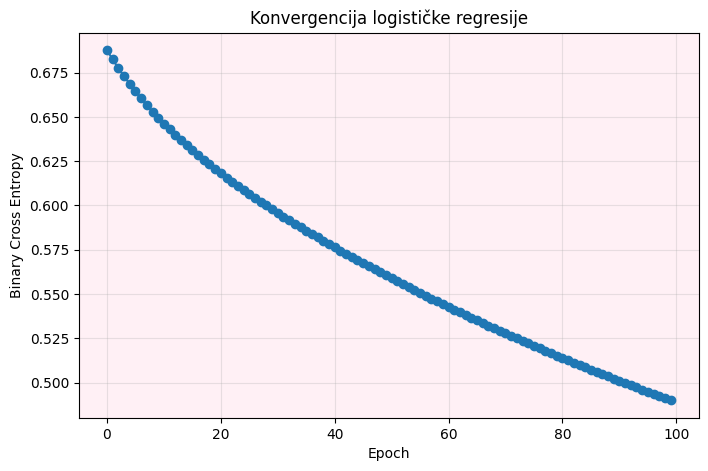

In [17]:
plt.figure(figsize=(8,5))

plt.plot(losses_class, marker='o')
plt.gca().set_facecolor("#fff0f5")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy")
plt.title("Konvergencija logističke regresije")

plt.grid(True, alpha=0.3)

plt.show()

Graf prikazuje smanjenje Binary Cross-Entropy funkcije greske tokom epoha, sto ukazuje na uspesnu konvergenciju modela.
Kriva opada glatko bez oscilacija, sto znači da je odabrana stopa ucenja adekvatna i da model stabilno uci.
Posto vrednost greske i dalje blago opada na kraju, moze se zaključiti da bi dodatne epohe mogle dovesti do jos boljih performansi modela.

## Odgovori na pitanja

1.Sta je sigmoid funkcija

Sigmoid funkcija transformise ulazne vrednosti u interval izmedju 0 i 1, cime omogucava interpretaciju rezultata kao verovatnoce pripadnosti klasi.

2.Kako regularizacija utice na model?

Regularizacija pomaze u smanjenju preprilagođavanja modela tako što kaznjava velike vrednosti parametara.

Koji su izazovi polinomskih karakteristika?

Veci broj polinomskih karakteristika moze dovesti do povecane slozenosti modela, sporijeg treniranja i rizika od overfitting-a. Ovi problemi se mogu ublaziti regularizacijom, pazljivim izborom stepena polinoma i vecom kolicinom podataka.